# Corr between human gene 3'UTR conservation and mRNA half-life  
Half-life data: Saluki paper PC1 as aggregated half-lives  
Conservation of 3'UTR: MANE 3'UTR (retrieved from UCSC Table Browser, strandness checked), methods from https://www.biorxiv.org/content/10.1101/2025.07.02.662873v1.full:  
To determine the number of conserved nucleotides in human 3′UTRs, we used a minimum phyloP score ≥ 2 and counted the nucleotides if at least four consecutive nucleotides had phyloP scores above this cutoff.  

In [26]:
import pandas as pd
import pyBigWig
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from pyfaidx import Fasta
import pingouin as pg

from matplotlib import font_manager
import matplotlib as mpl

arial_path = "/media/scratch/fy2306/tools/fonts"
font_files = font_manager.findSystemFonts(fontpaths=arial_path)

for file in font_files:
    font_manager.fontManager.addfont(file)
    
mpl.rcParams['font.family'] = 'Arial'

In [27]:
mane_map_path = "/media/dna/fy2306/genomes/hg38/MANE/release_1.4/MANE.GRCh38.v1.4.summary.txt"
mane_3utr_path = "/media/dna/fy2306/genomes/hg38/MANE/release_1.4/MANE_3UTR.bed"
phyloP_path = "/media/rna/fy2306/hg38.phyloP100way.bw"
hl_path = "/media/scratch/fy2306/projects/base_editing/data/conservation/saluki_all_HLs_human_PC1.txt"
hg38_path = "/media/dna/fy2306/genomes/hg38/GENCODE/GRCh38.primary_assembly.genome.fa"

In [28]:
# load in MANE 3'UTR
mane_3utr = pd.read_csv(mane_3utr_path, sep="\t", header=None, names=["chrom", "start", "end", "name", "score", "strand"])	# 0-based
mane_3utr["Ensembl_nuc"] = mane_3utr["name"].str.split("_").str[0]

# map to gene id
mane_map = pd.read_csv(mane_map_path, sep = "\t", usecols=['Ensembl_Gene', 'Ensembl_nuc'])
mane_3utr = mane_3utr.merge(mane_map, on="Ensembl_nuc", how="left")
mane_3utr["Ensembl_Gene"] = mane_3utr["Ensembl_Gene"].str.split(".").str[0]

# merge with HL
df_hl = pd.read_csv(hl_path, sep="\t")
mane_3utr = mane_3utr.merge(df_hl, left_on='Ensembl_Gene', right_on='ensembl_gene_id', how='inner')

In [29]:
# load in phyloP
bw = pyBigWig.open("/media/rna/fy2306/hg38.phyloP100way.bw")
# bigWig and pybigwig use 0-based half-open coordinates

In [30]:
def count_highly_conserved(values, cutoff=2.0, min_run=4) -> int:

    if not values:
        return 0

    arr = np.asarray(values, dtype=float)

    good = np.isfinite(arr) & (arr >= cutoff)
    if not np.any(good):
        return 0

    m = good.astype(np.int8)
    diff = np.diff(np.concatenate(([0], m, [0])))
    starts = np.where(diff == 1)[0]          # run starts (inclusive)
    ends   = np.where(diff == -1)[0]         # run ends (exclusive)
    lengths = ends - starts

    return int(lengths[lengths >= min_run].sum())

In [ ]:
# def conserved_in_row(row):
#     vals = bw.values(str(row.chrom), int(row.start), int(row.end))
#     return count_highly_conserved(vals, cutoff=2.0, min_run=4)

results = []
for r in mane_3utr.itertuples(index=False):
    vals = bw.values(str(r.chrom), int(r.start), int(r.end))
    results.append(count_highly_conserved(vals, cutoff=2.0, min_run=4))

mane_3utr["highly_conserved_bases"] = results
mane_3utr['length']	= mane_3utr['end'] - mane_3utr['start']
mane_3utr['conservation_fraction'] = mane_3utr['highly_conserved_bases'] / mane_3utr['length']
mane_3utr['highly_conserved_bases_log'] = np.log10(mane_3utr['highly_conserved_bases'] + 1)

In [32]:
# add GC content
fasta = Fasta(hg38_path)

def gc_content(chrom, start, end):
    seq = fasta[chrom][start:end].seq.upper()
    gc = (seq.count("G") + seq.count("C")) / len(seq)
    return gc

# Apply function to DataFrame
mane_3utr["GC_content"] = mane_3utr.apply(
    lambda row: gc_content(row.chrom, int(row.start), int(row.end)), axis=1
)

In [33]:
mane_3utr[mane_3utr["external_gene_name"].isin(["KDM6A", "KDM6B", "MYC"])]

,chrom,start,end,name,score,strand,Ensembl_nuc,Ensembl_Gene,ensembl_gene_id,external_gene_name,human_PC1,highly_conserved_bases,length,conservation_fraction,highly_conserved_bases_log,GC_content
6155,chr8,127740958,127742951,ENST00000621592.8_utr3_2_0_chr8_127740959_f,0,+,ENST00000621592.8,ENSG00000136997,ENSG00000136997,MYC,-14.630160,151,1993,0.075765,2.181844,0.389865
6910,chrX,45111411,45112779,ENST00000611820.5_utr3_29_0_chrX_45111412_f,0,+,ENST00000611820.5,ENSG00000147050,ENSG00000147050,KDM6A,-6.797777,956,1368,0.698830,2.980912,0.303363
11367,chr17,7853521,7854796,ENST00000448097.7_utr3_23_0_chr17_7853522_f,0,+,ENST00000448097.7,ENSG00000132510,ENSG00000132510,KDM6B,-6.076892,208,1275,0.163137,2.320146,0.549804


Pearson r = -0.192, p-value = 5.636e-118


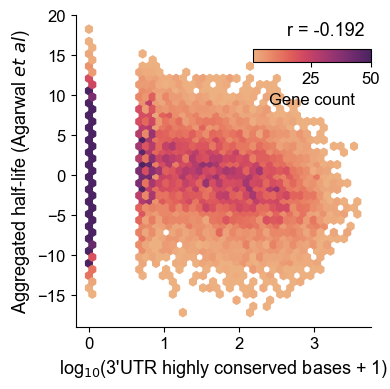

In [49]:
# mane_3utr = mane_3utr[mane_3utr["highly_conserved_bases"] > 0]
x = mane_3utr["highly_conserved_bases_log"]
y = mane_3utr["human_PC1"]

r, p_value = stats.pearsonr(x, y)
print(f"Pearson r = {r:.3f}, p-value = {p_value:.3e}")

fig, ax = plt.subplots(figsize=(4, 4))

hb = ax.hexbin(x, y, gridsize=40, cmap="flare", mincnt=1, vmin=1, vmax=50)
ax.set_xlabel("log$_{10}$(3'UTR highly conserved bases + 1)", fontsize=13)
ax.set_ylabel(r"Aggregated half-life (Agarwal $\it{et}$ $\it{al}$)", fontsize=13)
ax.tick_params(axis="both", which="major", labelsize=12)

cax = ax.inset_axes([0.60, 0.85, 0.4, 0.04])
cb = fig.colorbar(hb, cax=cax, orientation="horizontal")
cb.set_label("Gene count", fontsize=12)
cb.ax.tick_params(labelsize=12)

ax.text(
    0.98, 0.98,                     
    f"r = {r:.3f}",
    transform=ax.transAxes,         
    ha="right", va="top",
    fontsize=13
)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/conservation/conservation_HL.pdf", 
				bbox_inches="tight",
				dpi=300,              
				transparent=True,
				format='pdf')
plt.show()

In [ ]:
# pcorr = pg.partial_corr(data=mane_3utr, x='highly_conserved_bases_log', y='human_PC1', covar='GC_content', method='pearson')
# print(pcorr)

# x = mane_3utr["GC_content"]
# y = mane_3utr["human_PC1"]

# r, p_value = stats.pearsonr(x, y)
# print(f"Pearson r = {r:.3f}, p-value = {p_value:.3e}")

# plt.hexbin(x, y, gridsize=40, cmap="flare", mincnt=1, vmin=1)
# plt.xlabel("GC_content")
# plt.ylabel("Human PC1 (aggregated half-life)")

# plt.show()

# x = mane_3utr["GC_content"]
# y = mane_3utr["highly_conserved_bases_log"]

# r, p_value = stats.pearsonr(x, y)
# print(f"Pearson r = {r:.3f}, p-value = {p_value:.3e}")

# plt.hexbin(x, y, gridsize=40, cmap="flare", mincnt=1, vmin=1)
# plt.xlabel("GC_content")
# plt.ylabel("conservation_fraction")

# plt.show()